In [1]:
#Task3: Gaussian Mixture Model
#Step1: Step 1: Create Two Clusters
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal

np.random.seed(42)

# Cluster 1
mean1 = [4.5, 1.8]
cov1 = [[0.2, 0.05],
        [0.05, 0.1]]

data1 = np.random.multivariate_normal(mean1, cov1, 100)

# Cluster 2
mean2 = [6.0, 2.5]
cov2 = [[0.3, -0.04],
        [-0.04, 0.2]]

data2 = np.random.multivariate_normal(mean2, cov2, 100)

# Combine
X = np.vstack((data1, data2))


In [2]:
#means → centers of clusters (high usage / low usage houses)

#covariances → spread of clusters

#weights → probability of each cluster
# We start with random guesses.


k = 2  # number of clusters

n, d = X.shape  # n samples, d features

# Initial means
means = X[np.random.choice(n, k, replace=False)]

# Initial covariance matrices
covariances = [np.cov(X.T) for _ in range(k)]

# Initial mixing coefficients
weights = np.ones(k) / k


In [3]:
iterations = 2

for step in range(iterations):

    # E-step
    responsibilities = np.zeros((n, k))
    for i in range(k):
        rv = multivariate_normal(means[i], covariances[i])
        responsibilities[:, i] = weights[i] * rv.pdf(X)
    responsibilities /= responsibilities.sum(axis=1, keepdims=True)

    # M-step
    Nk = responsibilities.sum(axis=0)
    weights = Nk / n
    means = np.dot(responsibilities.T, X) / Nk[:, np.newaxis]

    covariances = []
    for i in range(k):
        diff = X - means[i]
        cov = np.dot(responsibilities[:, i] * diff.T, diff) / Nk[i]
        covariances.append(cov)


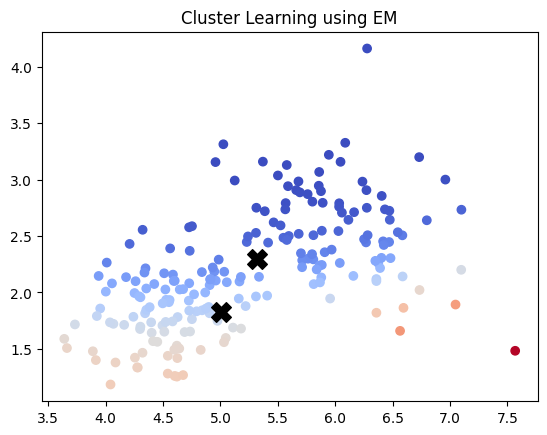

In [4]:
plt.scatter(X[:,0], X[:,1], c=responsibilities[:,0], cmap='coolwarm')
plt.scatter(means[:,0], means[:,1], c='black', marker='X', s=200)
plt.title("Cluster Learning using EM")
plt.show()


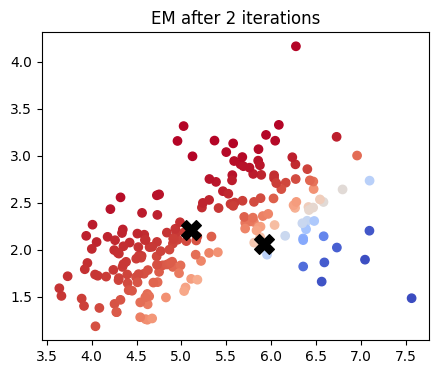

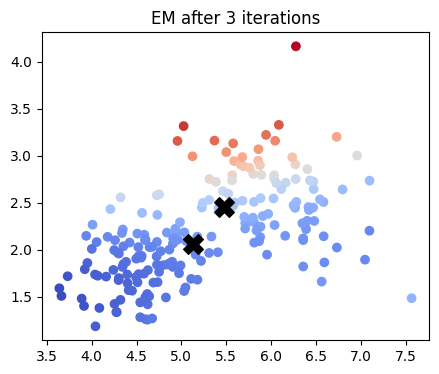

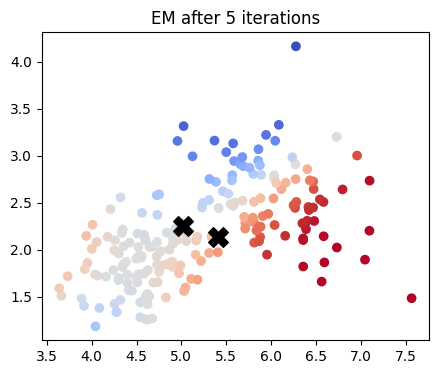

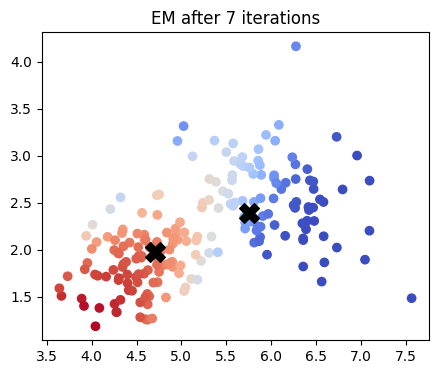

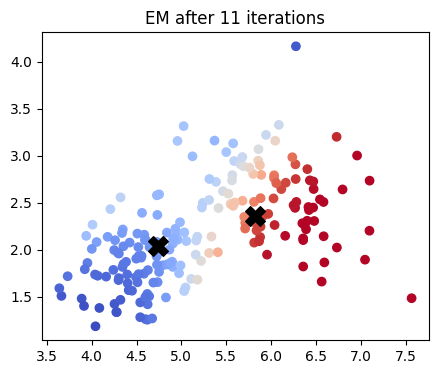

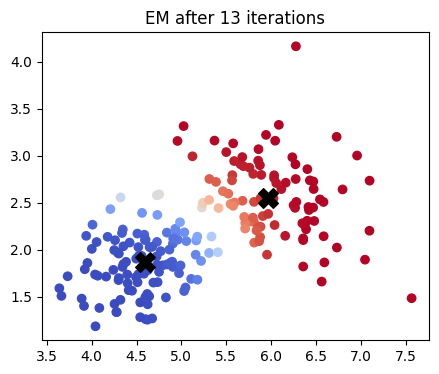

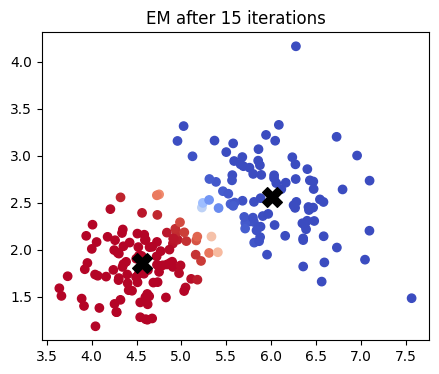

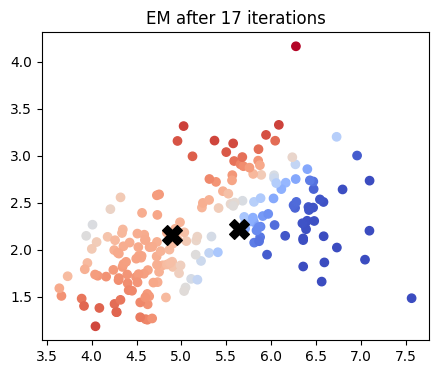

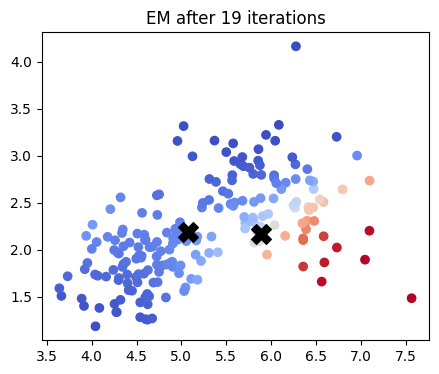

In [6]:
iteration_list = [2, 3, 5, 7, 11, 13, 15, 17, 19]

for iterations in iteration_list:
    
    # --- (Reinitialize parameters each time!) ---
    weights = np.ones(k) / k
    means = X[np.random.choice(n, k, replace=False)]
    covariances = [np.cov(X.T) for _ in range(k)]

    # ===== EM loop =====
    for step in range(iterations):

        # E-step
        responsibilities = np.zeros((n, k))
        for i in range(k):
            rv = multivariate_normal(mean=means[i], cov=covariances[i])
            responsibilities[:, i] = weights[i] * rv.pdf(X)

        responsibilities /= responsibilities.sum(axis=1, keepdims=True)

        # M-step
        Nk = responsibilities.sum(axis=0)
        weights = Nk / n
        means = np.dot(responsibilities.T, X) / Nk[:, np.newaxis]

        covariances = []
        for i in range(k):
            diff = X - means[i]
            cov = np.dot(responsibilities[:, i] * diff.T, diff) / Nk[i]
            covariances.append(cov)

    # ===== Plot for this iteration =====
    plt.figure(figsize=(5,4))
    plt.scatter(X[:,0], X[:,1], c=responsibilities[:,0], cmap='coolwarm')
    plt.scatter(means[:,0], means[:,1], c='black', marker='X', s=200)
    plt.title(f"EM after {iterations} iterations")
    plt.show()



========== Iterations = 2 ==========

Cluster 1
Mean: [5.02913959 2.01230546]
Variance: [0.67744848 0.17064902]
Std Dev: [0.82307259 0.41309686]

Cluster 2
Mean: [5.59066951 2.46839874]
Variance: [0.6050135 0.2624523]
Std Dev: [0.77782614 0.51230099]


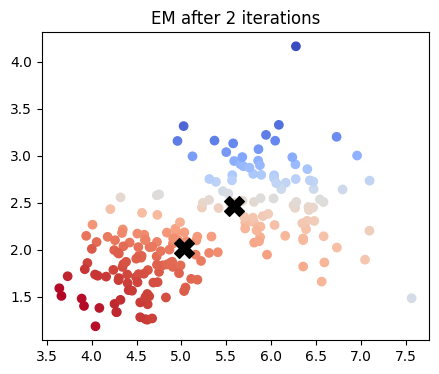

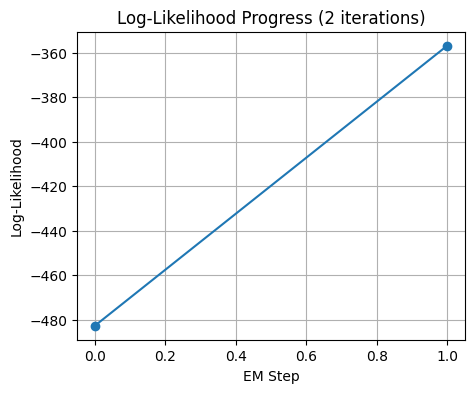


========== Iterations = 3 ==========

Cluster 1
Mean: [5.68831215 2.53337474]
Variance: [0.53817839 0.22830309]
Std Dev: [0.73360642 0.47781072]

Cluster 2
Mean: [4.94122968 1.95058463]
Variance: [0.62485712 0.13529852]
Std Dev: [0.79047904 0.36782948]


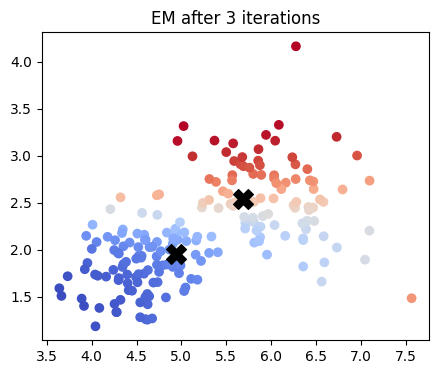

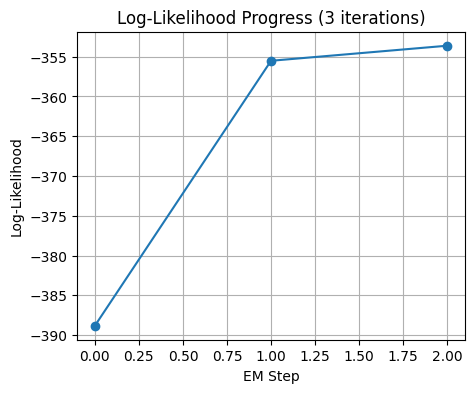


========== Iterations = 5 ==========

Cluster 1
Mean: [4.69594327 1.91540196]
Variance: [0.28216399 0.11868529]
Std Dev: [0.53119111 0.34450731]

Cluster 2
Mean: [6.05912581 2.58927394]
Variance: [0.27151434 0.18546677]
Std Dev: [0.52107038 0.43065853]


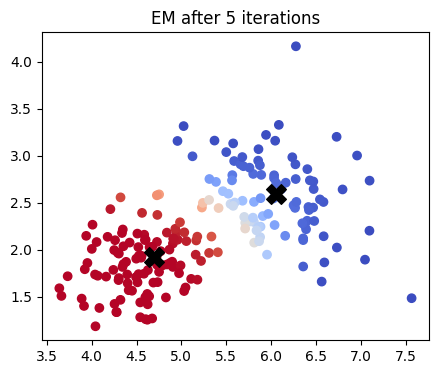

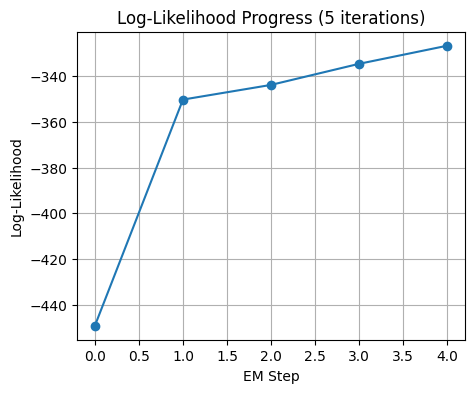


========== Iterations = 7 ==========

Cluster 1
Mean: [5.57429656 2.1502856 ]
Variance: [0.84311343 0.15341101]
Std Dev: [0.91821209 0.39167717]

Cluster 2
Mean: [4.99420414 2.21194021]
Variance: [0.49126791 0.32853294]
Std Dev: [0.70090506 0.57317793]


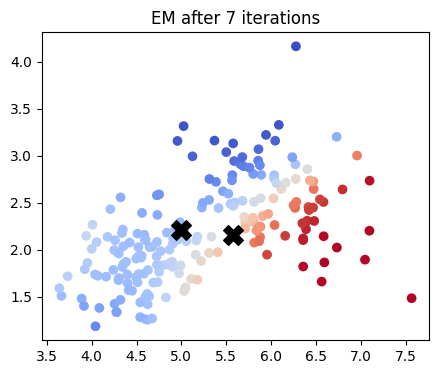

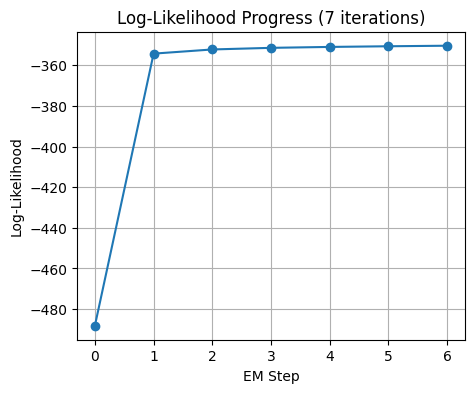


========== Iterations = 11 ==========

Cluster 1
Mean: [6.05465355 2.56773657]
Variance: [0.24105287 0.178539  ]
Std Dev: [0.49097135 0.42253875]

Cluster 2
Mean: [4.60747099 1.88677592]
Variance: [0.18301592 0.11046973]
Std Dev: [0.4278036  0.33236987]


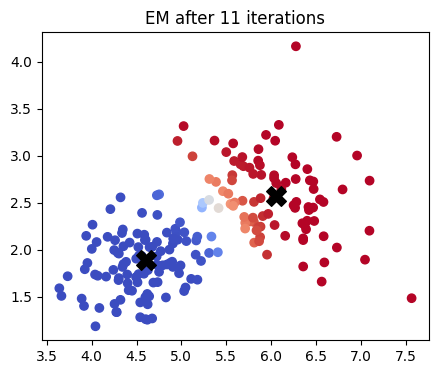

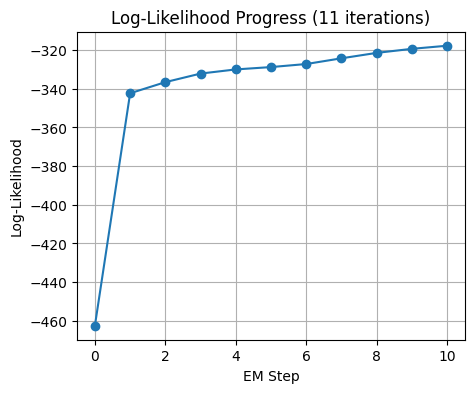


========== Iterations = 13 ==========

Cluster 1
Mean: [4.93240066 2.19023334]
Variance: [0.43208461 0.35221791]
Std Dev: [0.65733143 0.59347949]

Cluster 2
Mean: [5.52092033 2.18135577]
Variance: [0.82270886 0.16673812]
Std Dev: [0.907033   0.40833579]


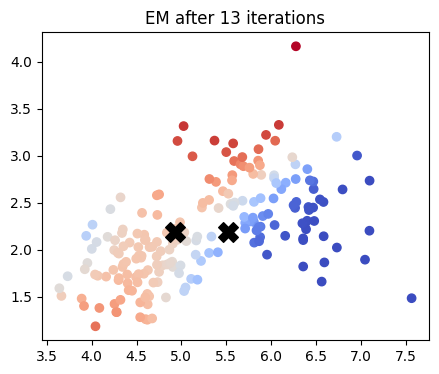

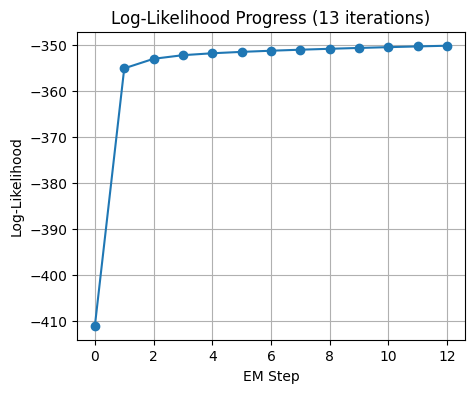


========== Iterations = 15 ==========

Cluster 1
Mean: [4.98722731 2.20513801]
Variance: [0.47842311 0.33809924]
Std Dev: [0.69168136 0.58146301]

Cluster 2
Mean: [5.54874665 2.16205503]
Variance: [0.84720659 0.1532056 ]
Std Dev: [0.92043826 0.39141487]


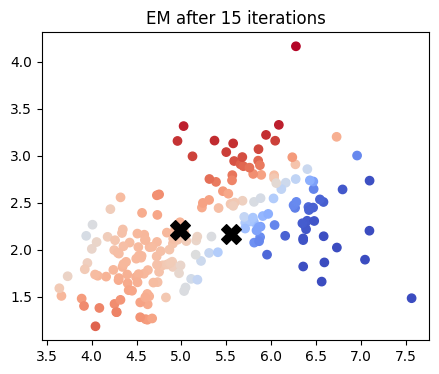

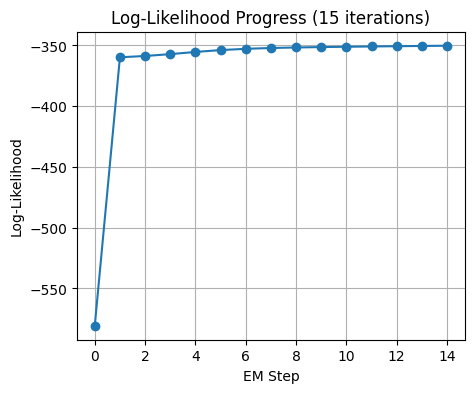


========== Iterations = 17 ==========

Cluster 1
Mean: [4.91514696 2.00953316]
Variance: [0.50659894 0.1554515 ]
Std Dev: [0.71175764 0.39427338]

Cluster 2
Mean: [6.09825454 2.64582379]
Variance: [0.28070661 0.22071588]
Std Dev: [0.52981752 0.46980408]


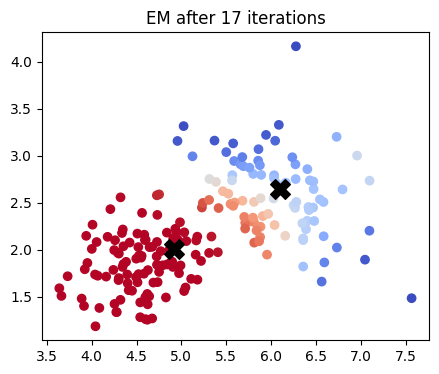

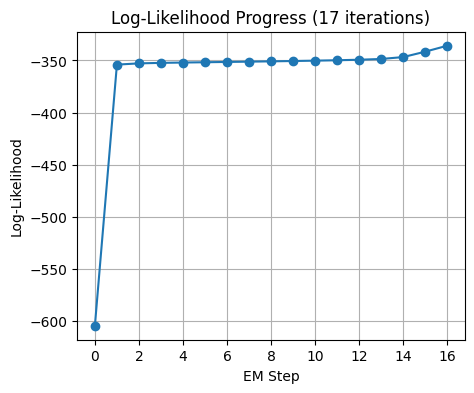


========== Iterations = 19 ==========

Cluster 1
Mean: [4.81656342 2.10667985]
Variance: [0.36380661 0.33578727]
Std Dev: [0.60316384 0.57947154]

Cluster 2
Mean: [5.6033707  2.25240395]
Variance: [0.74567003 0.17591266]
Std Dev: [0.86352188 0.41941943]


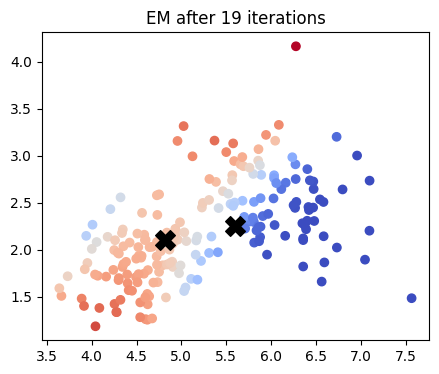

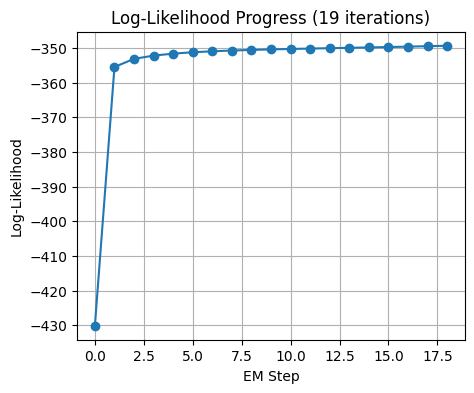

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal

iteration_list = [2, 3, 5, 7, 11, 13, 15, 17, 19]

results_summary = []

for iterations in iteration_list:

    print(f"\n========== Iterations = {iterations} ==========")

    # --- Reinitialize ---
    weights = np.ones(k) / k
    means = X[np.random.choice(n, k, replace=False)]
    covariances = [np.cov(X.T) for _ in range(k)]

    log_likelihoods = []

    # ===== EM loop =====
    for step in range(iterations):

        # -------- E-step --------
        responsibilities = np.zeros((n, k))
        for i in range(k):
            rv = multivariate_normal(mean=means[i], cov=covariances[i])
            responsibilities[:, i] = weights[i] * rv.pdf(X)

        total_prob = responsibilities.sum(axis=1)

        # log-likelihood
        log_likelihood = np.sum(np.log(total_prob + 1e-10))
        log_likelihoods.append(log_likelihood)

        responsibilities /= total_prob[:, np.newaxis]

        # -------- M-step --------
        Nk = responsibilities.sum(axis=0)
        weights = Nk / n

        # ✅ UPDATED MEANS
        means = np.dot(responsibilities.T, X) / Nk[:, np.newaxis]

        # ✅ UPDATED COVARIANCES
        covariances = []
        for i in range(k):
            diff = X - means[i]
            cov = np.dot(responsibilities[:, i] * diff.T, diff) / Nk[i]
            covariances.append(cov)

    # ===== VARIANCE & STD =====
    variances = [np.diag(cov) for cov in covariances]
    std_devs = [np.sqrt(var) for var in variances]

    # ===== PRINT (what you asked) =====
    for i in range(k):
        print(f"\nCluster {i+1}")
        print("Mean:", means[i])
        print("Variance:", variances[i])
        print("Std Dev:", std_devs[i])

    # ===== STORE FINAL LIST =====
    results_summary.append({
        "iterations": iterations,
        "means": means.copy(),
        "covariances": covariances.copy(),
        "variances": variances.copy(),
        "std_devs": std_devs.copy(),
        "log_likelihoods": log_likelihoods.copy()
    })

    # ===== CLUSTER PLOT =====
    plt.figure(figsize=(5,4))
    plt.scatter(X[:,0], X[:,1], c=responsibilities[:,0], cmap='coolwarm')
    plt.scatter(means[:,0], means[:,1], c='black', marker='X', s=200)
    plt.title(f"EM after {iterations} iterations")
    plt.show()

    # ===== LOG-LIKELIHOOD PLOT =====
    plt.figure(figsize=(5,4))
    plt.plot(log_likelihoods, marker='o')
    plt.title(f"Log-Likelihood Progress ({iterations} iterations)")
    plt.xlabel("EM Step")
    plt.ylabel("Log-Likelihood")
    plt.grid(True)
    plt.show()


In [12]:
import pandas as pd

table_rows = []

for res in results_summary:
    iterations = res["iterations"]
    final_ll = res["log_likelihoods"][-1]

    for cluster_id in range(k):
        table_rows.append({
            "Iteration_Label": iterations,      # ← your iteration list value
            "Cluster": cluster_id + 1,          # ← actual cluster number
            "Mean": res["means"][cluster_id],
            "Variance": res["variances"][cluster_id],
            "Final Log-Likelihood": final_ll
        })

final_table = pd.DataFrame(table_rows)

print("\n===== FINAL SUMMARY TABLE =====")
print(final_table)



===== FINAL SUMMARY TABLE =====
    Iteration_Label  Cluster                                     Mean  \
0                 2        1  [5.029139589810864, 2.0123054613579696]   
1                 2        2  [5.590669510683311, 2.4683987382726946]   
2                 3        1  [5.688312145876183, 2.5333747385578187]   
3                 3        2  [4.941229681039698, 1.9505846290772877]   
4                 5        1  [4.695943266970382, 1.9154019561547613]   
5                 5        2  [6.059125814765457, 2.5892739429195144]   
6                 7        1  [5.574296555292988, 2.1502855998998234]   
7                 7        2  [4.9942041421112355, 2.211940207429496]   
8                11        1  [6.054653545113997, 2.5677365704677237]   
9                11        2   [4.607470985373899, 1.886775919491122]   
10               13        1   [4.932400661389105, 2.190233337402877]   
11               13        2  [5.5209203295460565, 2.181355771588881]   
12               1

In [13]:
import pandas as pd

table_rows = []

for res in results_summary:
    iterations = res["iterations"]
    final_ll = res["log_likelihoods"][-1]

    for cluster_id in range(k):
        mean_x, mean_y = res["means"][cluster_id]
        var_x, var_y = res["variances"][cluster_id]

        table_rows.append({
            "Iterations": iterations,
            "Cluster": cluster_id + 1,
            "Mean_X": mean_x,
            "Mean_Y": mean_y,
            "Var_X": var_x,
            "Var_Y": var_y,
            "Final Log-Likelihood": final_ll
        })

final_table = pd.DataFrame(table_rows)
print(final_table)


    Iterations  Cluster    Mean_X    Mean_Y     Var_X     Var_Y  \
0            2        1  5.029140  2.012305  0.677448  0.170649   
1            2        2  5.590670  2.468399  0.605013  0.262452   
2            3        1  5.688312  2.533375  0.538178  0.228303   
3            3        2  4.941230  1.950585  0.624857  0.135299   
4            5        1  4.695943  1.915402  0.282164  0.118685   
5            5        2  6.059126  2.589274  0.271514  0.185467   
6            7        1  5.574297  2.150286  0.843113  0.153411   
7            7        2  4.994204  2.211940  0.491268  0.328533   
8           11        1  6.054654  2.567737  0.241053  0.178539   
9           11        2  4.607471  1.886776  0.183016  0.110470   
10          13        1  4.932401  2.190233  0.432085  0.352218   
11          13        2  5.520920  2.181356  0.822709  0.166738   
12          15        1  4.987227  2.205138  0.478423  0.338099   
13          15        2  5.548747  2.162055  0.847207  0.15320

In [14]:
# ===== Find best iteration =====

best_run = max(results_summary, key=lambda x: x["log_likelihoods"][-1])

best_iteration = best_run["iterations"]
best_ll = best_run["log_likelihoods"][-1]
best_means = best_run["means"]
best_variances = best_run["variances"]

print("\n===== BEST EM RUN =====")
print(f"Best Iteration Count: {best_iteration}")
print(f"Best Final Log-Likelihood: {best_ll:.6f}")

for i in range(k):
    print(f"\nCluster {i+1}")
    print("Mean:", best_means[i])
    print("Variance:", best_variances[i])



===== BEST EM RUN =====
Best Iteration Count: 11
Best Final Log-Likelihood: -317.738434

Cluster 1
Mean: [6.05465355 2.56773657]
Variance: [0.24105287 0.178539  ]

Cluster 2
Mean: [4.60747099 1.88677592]
Variance: [0.18301592 0.11046973]


In [15]:
best_ll = final_table["Final Log-Likelihood"].max()

print("\nBest rows in table:")
print(final_table[final_table["Final Log-Likelihood"] == best_ll])



Best rows in table:
   Iterations  Cluster    Mean_X    Mean_Y     Var_X     Var_Y  \
8          11        1  6.054654  2.567737  0.241053  0.178539   
9          11        2  4.607471  1.886776  0.183016  0.110470   

   Final Log-Likelihood  
8           -317.738434  
9           -317.738434  
